In [23]:
import os 
import glob 
import math

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [24]:
# windows
os.chdir("C:\\Users\\HP\\Desktop\\Research")

In [25]:
from codes.simulation_code.eucli_dist import mtm_varible_addition

In [48]:
# Define the path to the directory containing the CSV files
# windows
#path = 'data\\milano\\neighbor_pairs\\' 
#path = 'data\\milano\\for_mtm\\'  
path = 'data\\milano\\for_mtm_30\\'  

# Use glob to get all the CSV files in the directory
all_files = glob.glob(path + "leader_follower_pair_*.csv") #multiple neighbor
 
# Initialize an empty list to hold individual DataFrames
dfs = []

# Loop over the list of files and read each into a DataFrame, then append to the list
for filename in all_files:
    df = pd.read_csv(filename)
    dfs.append(df)

In [49]:
len(dfs)

315

In [57]:
# cut the unreliable corner values 
for i in range(len(dfs)):
    dfs[i] = dfs[i][(dfs[i]['x_rot'] > 50) & (dfs[i]['x_rot'] < 850)]
    
# reduce the frequency 
for i in range(len(dfs)): 
    dfs[i] = dfs[i].iloc[::5, :]
    

In [58]:
# change for the reverse. x values 
# only run one time otherwise re run the whole thing 
for i in range(len(dfs)): 
    
    dfs[i]['x_rot'] = 950 - dfs[i]['x_rot']
    dfs[i]['x_rot_1'] = 950 - dfs[i]['x_rot_1']
    dfs[i]['x_rot_2'] = 950 - dfs[i]['x_rot_2']
    dfs[i]['x_rot_3'] = 950 - dfs[i]['x_rot_3']
    dfs[i]['x_rot_4'] = 950 - dfs[i]['x_rot_4']   
    dfs[i]['x_rot_5'] = 950 - dfs[i]['x_rot_5']
    dfs[i]['x_rot_6'] = 950 - dfs[i]['x_rot_6']



In [59]:
dfs[98][['x_rot', 'x_rot_1', 'x_rot_2', 'x_rot_4', 'x_rot_5', 'x_rot_6']]

,x_rot,x_rot_1,x_rot_2,x_rot_4,x_rot_5,x_rot_6
100,100.436135,98.750091,NaN,191.989629,274.143393,554.967917
105,103.852855,NaN,NaN,103.866221,277.837390,557.678121
110,107.278524,NaN,NaN,108.946580,281.553748,560.383838
115,110.735503,NaN,NaN,114.004577,285.292441,563.098504
120,114.214843,NaN,NaN,119.058113,289.053495,565.799733
...,...,...,...,...,...,...
1385,888.299067,835.781880,690.738583,NaN,NaN,NaN
1390,891.107485,838.737975,693.784070,NaN,NaN,NaN
1395,893.920391,841.711944,696.816146,NaN,NaN,NaN
1400,896.755657,844.685912,699.852684,NaN,NaN,NaN


In [60]:
# calculate the euc. gap 
dfs_new = []

for df in dfs: 

    df_sample = df.copy()

    calc = mtm_varible_addition(df_sample)

    # cal. euc. gap. 
    updated_df =  calc.calcualte_gap()

    #long. acc. calculation. 
    updated_df = calc.lon_speed_calc()

    #lat. speed. calculation. 
    updated_df = calc.lat_speed_calc()

    #lat. acc. calculation. 
    updated_df = calc.lat_acc_calc()

    #long. acc. calculation. 
    updated_df = calc.lon_acc_calc()

    # boundary variables. addition 
    updated_df = calc.boundary_variables()

    # append to the new list. 
    dfs_new.append(updated_df)


In [61]:
# remove the last two records of each df. because of shiting caused by the new speed and acc. calculation. 
for i in range(len(dfs_new)): 
    dfs_new[i] = dfs_new[i].iloc[:-2]

In [50]:
df = dfs[55]
#df = dfs_new[55]

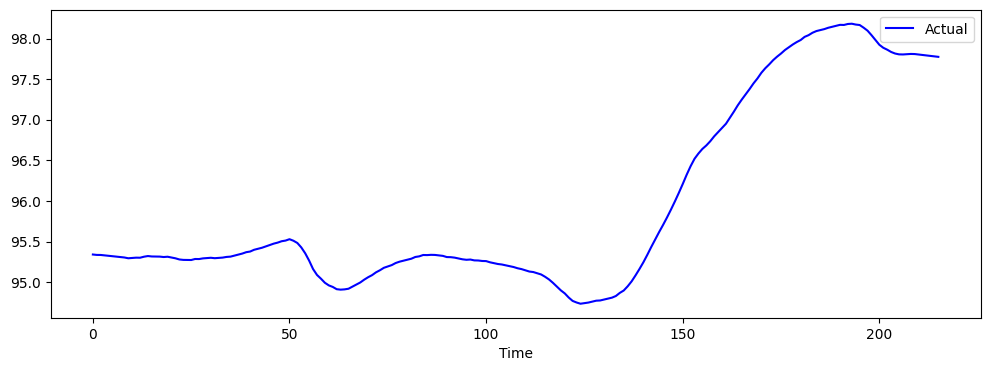

In [33]:
plt.figure(figsize=(12, 4))

plt.plot(df['y_rot'],   color='b',  label = 'Actual')
#plt.axhline(y=0, color='b', linestyle=':', linewidth=2, label='y = 0')

# plt.ylabel("Acc.")
plt.xlabel('Time')
plt.legend()

# plt.savefig('vehilce300_gap.jpg', dpi = 300)
plt.show()

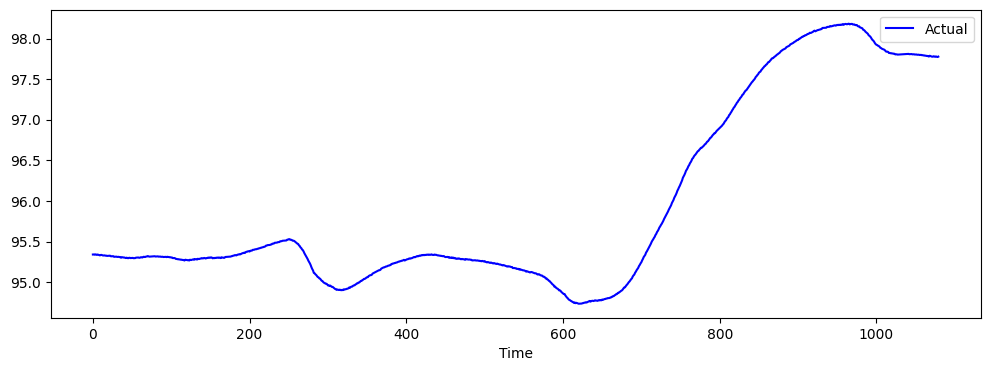

In [29]:
plt.figure(figsize=(12, 4))

plt.plot(df['y_rot'],   color='b',  label = 'Actual')
#plt.axhline(y=0, color='b', linestyle=':', linewidth=2, label='y = 0')

# plt.ylabel("Acc.")
plt.xlabel('Time')
plt.legend()

# plt.savefig('vehilce300_gap.jpg', dpi = 300)
plt.show()

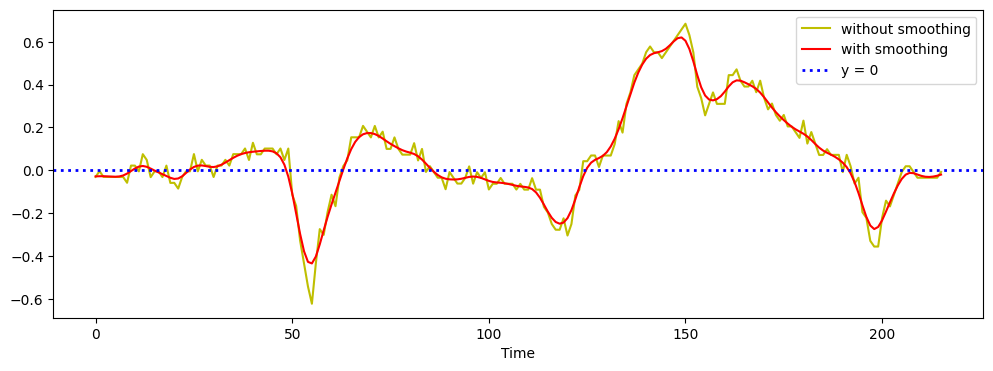

In [34]:
plt.figure(figsize=(12, 4))

plt.plot(df['Speed [km/h]_lat'],   color='y',  label = 'without smoothing')
plt.plot(df['Speed [km/h]_lat_f'],   color='r',  label = 'with smoothing')
plt.axhline(y=0, color='b', linestyle=':', linewidth=2, label='y = 0')

# plt.ylabel("Acc.")
plt.xlabel('Time')
plt.legend()

# plt.savefig('vehilce300_gap.jpg', dpi = 300)
plt.show()

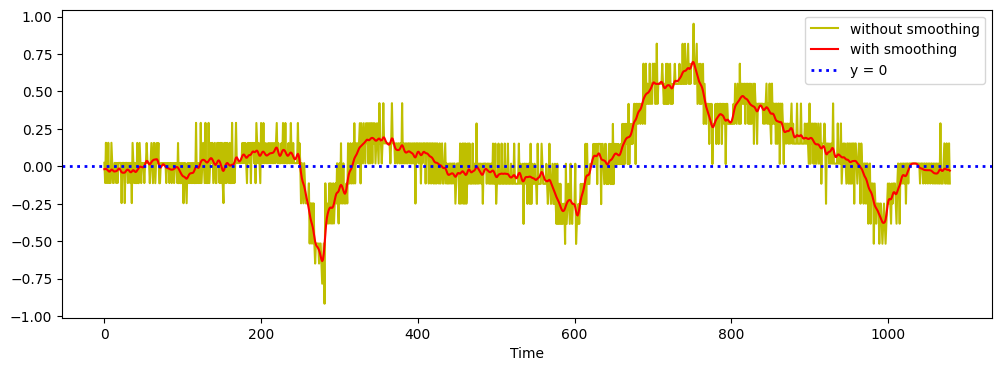

In [39]:
plt.figure(figsize=(12, 4))

plt.plot(df['Speed [km/h]_lat'],   color='y',  label = 'without smoothing')
plt.plot(df['Speed [km/h]_lat_f'],   color='r',  label = 'with smoothing')
plt.axhline(y=0, color='b', linestyle=':', linewidth=2, label='y = 0')

# plt.ylabel("Acc.")
plt.xlabel('Time')
plt.legend()

# plt.savefig('vehilce300_gap.jpg', dpi = 300)
plt.show()

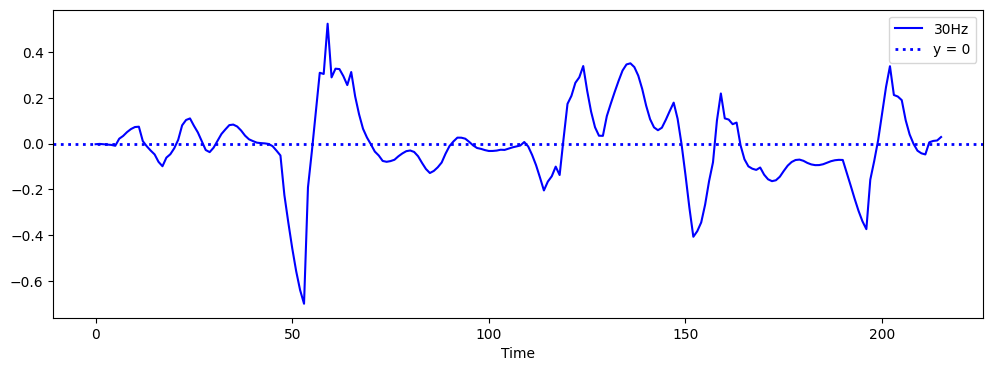

In [47]:
plt.figure(figsize=(12, 4))

plt.plot(df['Lat. Acc. [ms-2]'],   color='b',  label = '30Hz')
#plt.plot(df['Lat. Acc. [ms-2]_new'],   color='y',  label = '5Hz - calculated')
#plt.plot(df['Lat. Acc. [ms-2]_new_f'],   color='r',  label = '5Hz - smoothed')
#plt.plot(-df['Speed [km/h]_lat_f'],   color='r',  label = 'with smoothing')
#plt.plot(df['Lat. Acc. [ms-2]_new_new'],   color='red',  label = 'smooth')
plt.axhline(y=0, color='b', linestyle=':', linewidth=2, label='y = 0')

# plt.ylabel("Acc.")
plt.xlabel('Time')
plt.legend()

# plt.savefig('vehilce300_gap.jpg', dpi = 300)
plt.show()

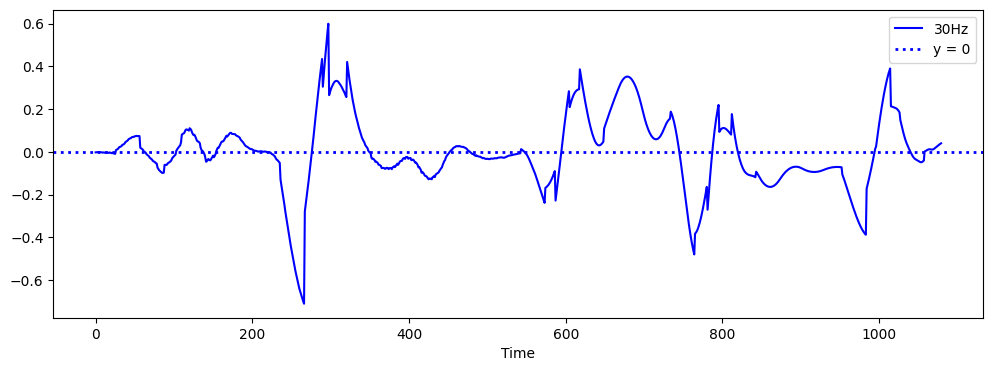

In [52]:
plt.figure(figsize=(12, 4))

plt.plot(df['Lat. Acc. [ms-2]'],   color='b',  label = '30Hz')
#plt.plot(df['Lat. Acc. [ms-2]_new'],   color='y',  label = '5Hz - calculated')
#plt.plot(df['Lat. Acc. [ms-2]_new_f'],   color='r',  label = '5Hz - smoothed')
#plt.plot(-df['Speed [km/h]_lat_f'],   color='r',  label = 'with smoothing')
#plt.plot(df['Lat. Acc. [ms-2]_new_new'],   color='red',  label = 'smooth')
plt.axhline(y=0, color='b', linestyle=':', linewidth=2, label='y = 0')

# plt.ylabel("Acc.")
plt.xlabel('Time')
plt.legend()

# plt.savefig('vehilce300_gap.jpg', dpi = 300)
plt.show()

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(df['Lat. Acc. [ms-2]'],   color='b',  label = '30Hz')
plt.plot(df['Lat. Acc. [ms-2]_new'],   color='y',  label = '5Hz - calculated')
plt.plot(df['Lat. Acc. [ms-2]_new_f'],   color='r',  label = '5Hz - smoothed')
#plt.plot(-df['Speed [km/h]_lat_f'],   color='r',  label = 'with smoothing')
#plt.plot(df['Lat. Acc. [ms-2]_new_new'],   color='red',  label = 'smooth')
plt.axhline(y=0, color='b', linestyle=':', linewidth=2, label='y = 0')

# plt.ylabel("Acc.")
plt.xlabel('Time')
plt.legend()

# plt.savefig('vehilce300_gap.jpg', dpi = 300)
plt.show()

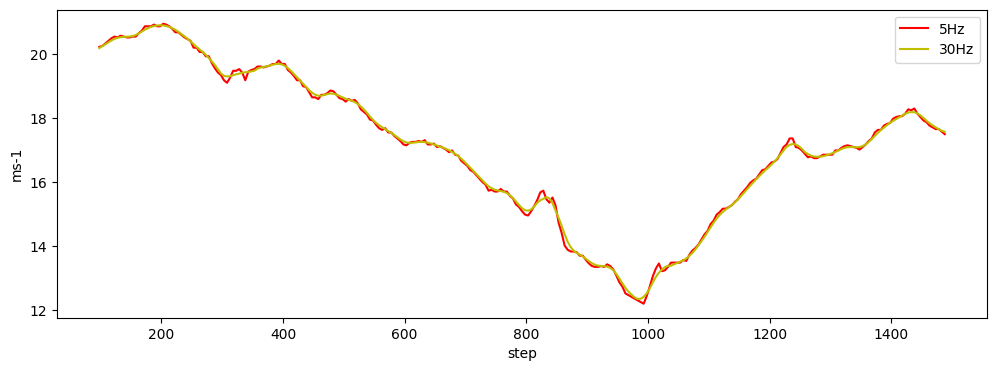

In [74]:
plt.figure(figsize=(12, 4))

plt.plot(df['Speed [km/h]_new'],   color='r',  label = '5Hz')
plt.plot(df['Speed [km/h]']*0.2777778 ,   color='y',  label = '30Hz')

#plt.axhline(y=0, color='b', linestyle=':', linewidth=2, label='y = 0')

# plt.ylabel("Acc.")
plt.xlabel('step')
plt.ylabel('ms-1')
plt.legend()

#plt.savefig('figures//5Hzvs30Hz_veh55.jpg', dpi = 300)
plt.show()

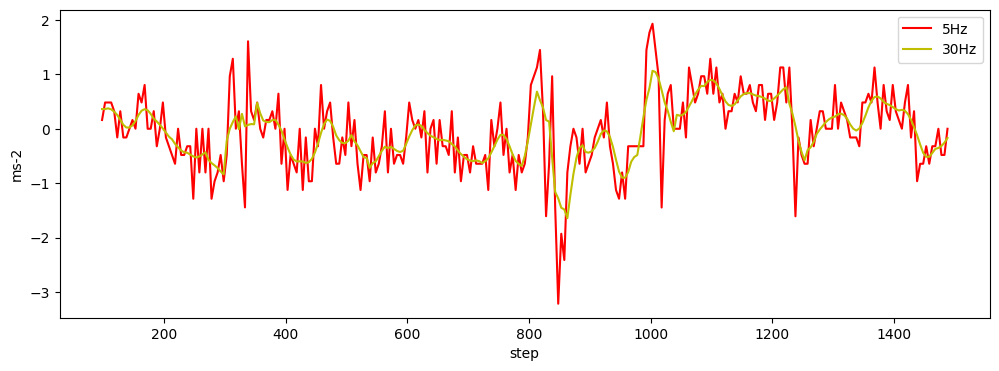

In [75]:
plt.figure(figsize=(12, 4))

#plt.plot(df['Tan. Acc. [ms-2]_o'],   color='b',  label = '5Hz - from original speed')
plt.plot(df['Tan. Acc. [ms-2]_new'],   color='r',  label = '5Hz')
plt.plot(df['Tan. Acc. [ms-2]'] ,   color='y',  label = '30Hz')
#plt.axhline(y=0, color='b', linestyle=':', linewidth=2, label='y = 0')

# plt.ylabel("Acc.")
plt.xlabel('step')
plt.ylabel('ms-2')
plt.legend()

#plt.savefig('figures//5Hzvs30Hz_veh55.jpg', dpi = 300)
plt.show()

In [68]:
def relative_feature_adding(dataframe): 
    
    """Adding the relative long gap. this is only for the use of IAM
    for IAAM the lat gap will be calculated by the model itself"""


    for idx, row in dataframe.iterrows():

        # This is based on the correct x direction. 
        # 1,2,3 are followers and 4,5,6 are leaders.
        dataframe.at[idx, 'Rel_x[m]_1'] = row['x_rot'] - row['x_rot_1'] - 0.5*(row['length'] + row['length_1'])
        dataframe.at[idx, 'Rel_x[m]_2'] = row['x_rot'] - row['x_rot_2'] - 0.5*(row['length'] + row['length_2'])
        dataframe.at[idx, 'Rel_x[m]_3'] = row['x_rot'] - row['x_rot_3'] - 0.5*(row['length'] + row['length_3'])
        
        dataframe.at[idx, 'Rel_x[m]_4'] = row['x_rot_4'] - row['x_rot']  - 0.5*(row['length'] + row['length_4'])
        dataframe.at[idx, 'Rel_x[m]_5'] = row['x_rot_5'] - row['x_rot']  - 0.5*(row['length'] + row['length_5'])
        dataframe.at[idx, 'Rel_x[m]_6'] = row['x_rot_6'] - row['x_rot']  - 0.5*(row['length'] + row['length_6'])

    
    return dataframe

# adding the relative variables for multiple neighbors 
for df in dfs_new: 
     df = relative_feature_adding(df)


C:\Users\HP\AppData\Local\Temp\ipykernel_22956\2206621763.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe.at[idx, 'Rel_x[m]_1'] = row['x_rot'] - row['x_rot_1'] - 0.5*(row['length'] + row['length_1'])
C:\Users\HP\AppData\Local\Temp\ipykernel_22956\2206621763.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe.at[idx, 'Rel_x[m]_2'] = row['x_rot'] - row['x_rot_2'] - 0.5*(row['length'] + row['length_2'])
C:\Users\HP\AppData\Local\Temp\ipykernel_22956\2206621763.py:13: SettingWithCopyWa

In [69]:
## filter the subjects within the range that has an impact from the neighbor vehicles. 

'''
the minimum x value is 100 and maximum is 895. 
for IAM - we neglect the subject instances in the first 100m and the last 100m because the subjects within that region may not capture all the neighbors that are outside of the region. 
no we are using the same for the NN model as well. since we can compare within the same conditions. 
'''
new_dfs_2 = []

for df in dfs_new: 
    
    # the range is based on the minimum and maximum x values 100 and 895. 
    df = df[(df['x_rot'] > 200) & (df['x_rot'] < 795)]

    new_dfs_2.append(df)
        
    

In [88]:
combined = pd.concat(new_dfs_2)

In [89]:
combined.describe()['x_rot']

count    46259.000000
mean       506.986348
std        171.042828
min        200.011459
25%        360.338550
50%        513.138424
75%        655.190126
max        794.993056
Name: x_rot, dtype: float64

In [90]:
combined.describe()['Rel_x[m]_6']

count    31946.000000
mean       101.277203
std        117.495640
min        -12.490448
25%         16.716032
50%         54.188398
75%        147.401845
max        716.804681
Name: Rel_x[m]_6, dtype: float64

In [ ]:
new_dfs_2[23]['Sp']

In [70]:
new_dfs_2[23]

,Unnamed: 0,x[m],y[m],Speed [km/h],Tan. Acc. [ms-2],Lat. Acc. [ms-2],Time [s],Angle [rad],vehicle_id,flw_type,...,Tan. Acc. [ms-2]_6_o,width_road,width_right,width_left,Rel_x[m]_1,Rel_x[m]_2,Rel_x[m]_3,Rel_x[m]_4,Rel_x[m]_5,Rel_x[m]_6
228,138378,512135.77,5026362.33,81.8719,-0.3356,-0.0181,26.726753,2.6807,169.0,Car,...,7.286328,15.5,9.419081,6.080919,73.034635,14.632461,NaN,59.457134,15.799982,299.346802
233,138383,512132.38,5026364.01,81.6585,-0.3767,-0.0140,26.893586,2.6810,169.0,Car,...,-0.579019,15.5,9.409960,6.090040,71.907652,14.636948,165.056338,60.092157,15.728438,283.263321
238,138388,512128.99,5026365.69,81.4227,-0.4075,-0.0056,27.060420,2.6811,169.0,Car,...,-0.727669,15.5,9.400839,6.099161,70.762771,14.668258,166.684281,60.776388,15.652407,281.814441
243,138393,512125.61,5026367.37,81.1557,-0.4388,0.0053,27.227254,2.6811,169.0,Car,...,-0.284116,15.5,9.396180,6.103820,69.617890,14.699568,168.298812,61.532163,15.545091,280.347663
248,138398,512122.24,5026369.04,80.8718,-0.5131,0.0102,27.394087,2.6810,169.0,Car,...,0.656341,15.5,9.387034,6.112966,68.468546,14.739828,169.908882,62.332660,15.410927,278.880859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1088,139238,511618.68,5026620.04,73.1622,0.4649,-0.0561,55.422143,2.6757,169.0,Car,...,-0.006593,14.5,9.328188,5.171812,117.634705,12.974528,55.587419,58.603145,35.010406,129.642992
1093,139243,511615.64,5026621.57,73.4422,0.4632,-0.0445,55.588976,2.6760,169.0,Car,...,-2.416174,14.5,9.340996,5.159004,116.579317,13.296629,55.757330,59.278452,34.979121,129.625042
1098,139248,511612.59,5026623.10,73.7158,0.4489,0.0110,55.755810,2.6760,169.0,Car,...,-5.842334,14.5,9.349343,5.150657,115.541828,13.632140,55.949601,59.967171,34.947837,129.656276
1103,139253,511609.54,5026624.64,73.9841,0.4468,0.0352,55.922644,2.6757,169.0,Car,...,-10.770051,14.5,9.366638,5.133362,114.499851,13.967626,56.146334,60.655889,34.912090,129.669637


In [71]:
# save the dfs. 
dfs = new_dfs_2

for df in dfs: 

    df_sample = df.copy()

    veh_id = df_sample["vehicle_id"].unique()[0]

    path = f"data\\milano\\for_mtm\\leader_follower_pair_{veh_id}.csv"
    
    df_sample.to_csv(path)
    